In [1]:
import re
import csv
import copy
import math
import json
import traceback
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import product
from scipy.optimize import root
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, SymLogNorm, Normalize, LinearSegmentedColormap
from matplotlib.ticker import ScalarFormatter
from matplotlib.patches import Circle, Patch
from scipy.sparse import csr_matrix, diags, eye
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from dataclasses import dataclass, replace, asdict, is_dataclass
from typing import Any, Dict, Iterable, Iterator, List, Mapping, Optional, Tuple

In [2]:
# ============================================================
# Loader for simulation scan JSONL output
# ============================================================
#
# Handles BOTH:
#   - aggregated multi-realization output of run_parameter_scan
#     (Multi-area_circuit_EI_sparse_scan_para.ipynb), where each numeric
#     diagnostic appears as <key>_mean, <key>_std, <key>_n_finite
#   - older single-realization output, where diagnostics carry their raw
#     names (x0_mean, R_max_real_eig, ...)
#
# Records are returned as a flat list of dicts so they can be fed
# directly to the theory-style plotting helpers (records_to_grid,
# plot_metric_heatmap, ...).

def decode_special_value(v):
    if v is None:
        return np.nan
    if isinstance(v, str):
        s = v.strip().upper()
        if s in {"__INF__", "INF", "+INF", "INFINITY", "+INFINITY"}:
            return np.inf
        if s in {"__-INF__", "-INF", "-INFINITY"}:
            return -np.inf
        if s in {"__NAN__", "NAN"}:
            return np.nan
    return v


def _decode_dict(d):
    return {k: decode_special_value(v) for k, v in d.items()}


def load_sim_records(path):
    """
    Load a simulation scan JSONL into a list of flat record dicts.

    Each record exposes:
      - all `params` keys at the top level
      - all `diagnostics` keys at the top level
      - for every <key>_mean field, an alias <key> pointing to the same
        value (so theory-style plotters that expect un-suffixed names
        just work)
      - `success` = 1 iff `status == "ok"` else 0
      - derived fixed-point keys:
          x_star_area0_minus_global   = x0_area0_mean - x0_mean
          x_star_area1_minus_global   = x0_area1_mean - x0_mean
          x_star_area_diff_0_minus_1  = x0_area0_mean - x0_area1_mean
      - derived combined-spectrum proxy:
          W_lambda_max = max(R_max_real_eig, eig_S)
      - aliases used by the theory plotting helpers:
          x_star_area0  := x0_area0_mean
          x_star_area1  := x0_area1_mean
          x_star_mean   := x0_mean
          x_star_max    := x0_max
          x_star_min    := x0_min
          rate_area0    := rate_area0_mean
          rate_area1    := rate_area1_mean
    """
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec_raw = json.loads(line)

            rec = {
                "scan_index": rec_raw.get("scan_index"),
                "success": 1 if rec_raw.get("status") == "ok" else 0,
                "n_realizations": rec_raw.get("n_realizations", 1),
            }

            params = _decode_dict(rec_raw.get("params", {}))
            diagnostics = _decode_dict(rec_raw.get("diagnostics", {}))
            meta = rec_raw.get("meta", {}) or {}

            rec.update(params)
            rec.update(diagnostics)

            for k, v in list(diagnostics.items()):
                if k.endswith("_mean"):
                    base = k[: -len("_mean")]
                    if base not in rec:
                        rec[base] = v

            rec.setdefault(
                "fixed_point_success_fraction",
                rec.get("fixed_point_success", 1.0),
            )

            alias_map = {
                "x_star_area0": "x0_area0_mean",
                "x_star_area1": "x0_area1_mean",
                "x_star_mean":  "x0_mean",
                "x_star_max":   "x0_max",
                "x_star_min":   "x0_min",
                "rate_area0":   "rate_area0_mean",
                "rate_area1":   "rate_area1_mean",
            }
            for new_key, src_key in alias_map.items():
                if src_key in rec and new_key not in rec:
                    rec[new_key] = rec[src_key]

            def _f(name):
                v = rec.get(name, np.nan)
                try:
                    return float(v)
                except Exception:
                    return np.nan

            x0_area0 = _f("x_star_area0")
            x0_area1 = _f("x_star_area1")
            x0_glob  = _f("x_star_mean")
            rec["x_star_area0_minus_global"]  = x0_area0 - x0_glob
            rec["x_star_area1_minus_global"]  = x0_area1 - x0_glob
            rec["x_star_area_diff_0_minus_1"] = x0_area0 - x0_area1

            R_eig = _f("R_max_real_eig")
            S_eig = _f("eig_S")
            if np.isfinite(R_eig) and np.isfinite(S_eig):
                rec["W_lambda_max"] = float(max(R_eig, S_eig))
            else:
                rec["W_lambda_max"] = np.nan

            for k, v in meta.items():
                rec.setdefault(f"meta.{k}", v)

            records.append(rec)

    return add_connection_count_coordinates(records)


def add_connection_count_coordinates(records):
    """Add plotting coordinates that express sparsities as in-degree counts.

    The scan itself stays in sparsity coordinates; these derived keys are
    only for plotting axes. Local counts use C_within = round(s * N).
    Cross-area counts use only the excitatory source pool.
    """
    enriched = []
    for r in records:
        rr = dict(r)

        area_ids = sorted({
            int(k.split("]")[0][len("areas["):])
            for k in rr
            if k.startswith("areas[") and "]." in k
        })

        n_exc_by_area = {}
        for area_id in area_ids:
            try:
                N = int(round(float(rr[f"areas[{area_id}].N"])))
                s_within = float(rr[f"areas[{area_id}].s"])
                f_exc = float(rr[f"areas[{area_id}].f_exc"])
            except Exception:
                continue

            C_within = int(round(s_within * N))
            C_E = int(round(f_exc * C_within))
            C_I = C_within - C_E
            N_E = int(round(f_exc * N))

            rr[f"C_within[{area_id}]"] = C_within
            rr[f"C_E[{area_id}]"] = C_E
            rr[f"C_I[{area_id}]"] = C_I
            n_exc_by_area[area_id] = N_E

        for key, value in list(rr.items()):
            if not (key.startswith("s_cross[") and key.endswith("]")):
                continue
            try:
                src_s, tgt_s = key[len("s_cross["):-1].split(",")
                src = int(src_s)
                tgt = int(tgt_s)
                N_E_src = n_exc_by_area[src]
                s_cross = float(value)
            except Exception:
                continue
            rr[f"C_cross[{src},{tgt}]"] = int(round(s_cross * N_E_src))

        enriched.append(rr)
    return enriched


_FIXED_POINT_METRIC_KEYS = (
    "x_star_area0",
    "x_star_area1",
    "x_star_mean",
    "x_star_max",
    "x_star_min",
    "rate_area0",
    "rate_area1",
    "x_star_area0_minus_global",
    "x_star_area1_minus_global",
    "x_star_area_diff_0_minus_1",
    "x0_mean",
    "x0_max",
    "x0_min",
    "x0_area0_mean",
    "x0_area1_mean",
    "rate_area0_mean",
    "rate_area1_mean",
)


def mask_sim_records(records, min_success_fraction=1.0):
    """Mask fixed-point metrics to NaN for non-converged records."""
    masked = []
    for r in records:
        rr = dict(r)
        ok = rr.get("success", 0) == 1
        frac = rr.get(
            "fixed_point_success_fraction",
            rr.get("fixed_point_success", 1.0),
        )
        try:
            ok = ok and float(frac) >= float(min_success_fraction)
        except Exception:
            ok = False
        if not ok:
            for key in _FIXED_POINT_METRIC_KEYS:
                if key in rr:
                    rr[key] = np.nan
        masked.append(rr)
    return masked

In [3]:
# ============================================================
# Theory-style heatmap helpers
# (copied from Draw_theory_prediction.ipynb so this notebook is
#  self-contained; same visual language)
# ============================================================

def _canonical_float(x, ndigits=12):
    return round(float(x), ndigits)


def records_to_grid(records, x_key, y_key, z_key):
    valid = []
    for r in records:
        if r.get("success", 0) != 1:
            continue
        if x_key not in r or y_key not in r or z_key not in r:
            continue
        valid.append(r)

    if len(valid) == 0:
        raise ValueError("No valid records found for the requested keys.")

    x_vals = sorted({_canonical_float(r[x_key]) for r in valid})
    y_vals = sorted({_canonical_float(r[y_key]) for r in valid})

    x_index = {v: i for i, v in enumerate(x_vals)}
    y_index = {v: i for i, v in enumerate(y_vals)}

    Z = np.full((len(y_vals), len(x_vals)), np.nan, dtype=float)
    # If multiple records share the same plotted (x, y), the later one overwrites
    # the earlier one. Some legacy scans vary an unplotted parameter this way.
    for r in valid:
        x = _canonical_float(r[x_key])
        y = _canonical_float(r[y_key])
        try:
            z = float(r[z_key])
        except Exception:
            z = np.nan
        Z[y_index[y], x_index[x]] = z

    return np.asarray(x_vals), np.asarray(y_vals), Z


def _critical_cell_center_points(x_values, y_values, Z, contour_level, nearest_tol=None):
    """Cell centers of the boundary Z == contour_level.

    For every row and every column we look at consecutive *finite* cells and
    mark a boundary cell whenever (Z - level) changes sign (or equals zero
    exactly). The cell whose value is closer to the level is selected; corner
    cells flagged from both row and column scans deduplicate naturally
    because we collect (row_idx, col_idx) tuples in a set.

    The collected cell centers are then ordered along the path via a greedy
    nearest-neighbor traversal starting from the lower-left point, so the
    returned (N, 2) array can be drawn as a single connected polyline.

    `nearest_tol` is accepted for backwards compatibility with the previous
    signature but is unused: the algorithm only ever places points at true
    sign changes, never at a "closest finite cell" fallback.
    """
    del nearest_tol  # unused; kept for caller compatibility

    Z = np.asarray(Z, dtype=float)
    finite_mask = np.isfinite(Z)
    if not np.any(finite_mask):
        return np.empty((0, 2), dtype=float)

    level = float(contour_level)
    boundary_cells = set()  # {(row_idx, col_idx)}

    def consider(idx_a, idx_b, v_a, v_b, register):
        d_a = v_a - level
        d_b = v_b - level
        if d_a == 0.0:
            register(idx_a)
        if d_b == 0.0:
            register(idx_b)
        if d_a * d_b < 0.0:
            if abs(d_a) <= abs(d_b):
                register(idx_a)
            else:
                register(idx_b)

    for i in range(Z.shape[0]):
        valid = np.flatnonzero(finite_mask[i, :])
        if valid.size == 1 and Z[i, valid[0]] == level:
            boundary_cells.add((i, int(valid[0])))
        for a, b in zip(valid[:-1], valid[1:]):
            consider(
                int(a), int(b), Z[i, a], Z[i, b],
                lambda j, ii=i: boundary_cells.add((ii, j)),
            )

    for j in range(Z.shape[1]):
        valid = np.flatnonzero(finite_mask[:, j])
        if valid.size == 1 and Z[valid[0], j] == level:
            boundary_cells.add((int(valid[0]), j))
        for a, b in zip(valid[:-1], valid[1:]):
            consider(
                int(a), int(b), Z[a, j], Z[b, j],
                lambda i, jj=j: boundary_cells.add((i, jj)),
            )

    if not boundary_cells:
        return np.empty((0, 2), dtype=float)

    pts = np.asarray(
        [(x_values[j], y_values[i]) for (i, j) in boundary_cells],
        dtype=float,
    )
    if pts.shape[0] <= 1:
        return pts

    start = int(np.lexsort((pts[:, 1], pts[:, 0]))[0])
    order = [start]
    remaining = set(range(pts.shape[0])) - {start}
    while remaining:
        cur = pts[order[-1]]
        nxt = min(remaining, key=lambda k: float(np.hypot(*(pts[k] - cur))))
        order.append(nxt)
        remaining.remove(nxt)
    return pts[order]

def _cutoff_diverging_cmap(cmap_obj, cutoff, vmin, vmax, n=256):
    if not (np.isfinite(vmin) and np.isfinite(vmax) and vmin < cutoff < vmax):
        return cmap_obj

    cutoff_pos = (float(cutoff) - float(vmin)) / (float(vmax) - float(vmin))
    positions = np.unique(np.concatenate([np.linspace(0.0, 1.0, n), [cutoff_pos]]))
    sample_positions = np.empty_like(positions)

    below = positions <= cutoff_pos
    sample_positions[below] = 0.5 * positions[below] / cutoff_pos
    sample_positions[~below] = 0.5 + 0.5 * (positions[~below] - cutoff_pos) / (1.0 - cutoff_pos)

    colors = cmap_obj(sample_positions)
    return LinearSegmentedColormap.from_list(
        f"{cmap_obj.name}_cutoff_{cutoff:g}",
        list(zip(positions, colors)),
        N=len(positions),
    )


def plot_metric_heatmap(
    records,
    x_key,
    y_key,
    z_key,
    title=None,
    xlabel=None,
    ylabel=None,
    cbar_label=None,
    contour_level=1.0,
    ax=None,
    cmap="viridis",
    invalid_color="0.5",
    center=None,
    vmin=None,
    vmax=None,
    value_scale="linear",
    linthresh=None,
    color_cutoff=None,
    contour_mode="interpolated",
    contour_nearest_tol=None,
    clip=True,
):
    x_values, y_values, Z = records_to_grid(records, x_key, y_key, z_key)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    cmap_obj = plt.get_cmap(cmap).copy()

    Zm = np.ma.masked_invalid(Z)
    X, Y = np.meshgrid(x_values, y_values)

    norm = None
    if value_scale == "symlog":
        finite_vals = Z[np.isfinite(Z)]
        if finite_vals.size > 0:
            if vmin is None or vmax is None:
                scale_center = center if center is not None else 0.0
                scale = float(np.nanmax(np.abs(finite_vals - scale_center)))
                if scale == 0.0:
                    scale = 1.0
                if vmin is None:
                    vmin = scale_center - scale
                if vmax is None:
                    vmax = scale_center + scale
            lt = linthresh
            if lt is None:
                lt = max(abs(vmax), abs(vmin)) / 100.0
                if lt <= 0.0:
                    lt = 1.0
            norm = SymLogNorm(linthresh=lt, vmin=vmin, vmax=vmax, base=10)
    elif center is not None:
        finite_vals = Z[np.isfinite(Z)]
        if finite_vals.size > 0:
            if vmin is None or vmax is None:
                scale = float(np.nanmax(np.abs(finite_vals - center)))
                if scale == 0.0:
                    scale = 1.0
                if vmin is None:
                    vmin = center - scale
                if vmax is None:
                    vmax = center + scale
            if vmin < center < vmax:
                norm = TwoSlopeNorm(vmin=vmin, vcenter=center, vmax=vmax)
    elif color_cutoff is not None:
        finite_vals = Z[np.isfinite(Z)]
        if finite_vals.size > 0:
            if vmin is None:
                vmin = float(np.nanmin(finite_vals))
            if vmax is None:
                vmax = float(np.nanmax(finite_vals))
            if vmin < color_cutoff < vmax:
                norm = Normalize(vmin=vmin, vmax=vmax)

    if value_scale == "linear" and color_cutoff is not None and type(norm) is Normalize:
        if vmin is not None and vmax is not None:
            cmap_obj = _cutoff_diverging_cmap(cmap_obj, color_cutoff, vmin, vmax)

    cmap_obj = cmap_obj.copy()
    cmap_obj.set_bad(color=invalid_color)
    if clip:
        cmap_obj.set_over(cmap_obj(1.0))
        cmap_obj.set_under(cmap_obj(0.0))

    extend = "neither"
    if clip and np.any(np.isfinite(Z)):
        finite_vals = Z[np.isfinite(Z)]
        over = vmax is not None and np.any(finite_vals > vmax)
        under = vmin is not None and np.any(finite_vals < vmin)
        if over and under:
            extend = "both"
        elif over:
            extend = "max"
        elif under:
            extend = "min"

    im = ax.pcolormesh(
        X, Y, Zm,
        shading="nearest",
        cmap=cmap_obj,
        norm=norm,
        vmin=None if norm else vmin,
        vmax=None if norm else vmax,
    )
    cbar = plt.colorbar(im, ax=ax, extend=extend)
    cbar.set_label(cbar_label if cbar_label is not None else z_key, fontsize=16)
    cbar.ax.tick_params(labelsize=13)

    if contour_level is not None and np.any(np.isfinite(Z)):
        zmin = np.nanmin(Z)
        zmax = np.nanmax(Z)
        if contour_mode == "interpolated":
            if zmin <= contour_level <= zmax:
                ax.contour(X, Y, Z, levels=[contour_level], colors="red", linewidths=2.0)
        elif contour_mode == "cell_centers":
            centers = _critical_cell_center_points(
                x_values, y_values, Z,
                contour_level,
                nearest_tol=contour_nearest_tol,
            )
            if centers.shape[0] >= 2:
                ax.plot(centers[:, 0], centers[:, 1], color="red", linewidth=2.0)
            elif centers.shape[0] == 1:
                ax.plot(centers[:, 0], centers[:, 1], marker="o", color="red", markersize=4)
        else:
            raise ValueError("contour_mode must be 'interpolated' or 'cell_centers'")

    ax.set_title(title if title is not None else z_key, fontsize=18)
    ax.set_xlabel(xlabel if xlabel is not None else x_key, fontsize=18)
    ax.set_ylabel(ylabel if ylabel is not None else y_key, fontsize=18)

    if np.any(~np.isfinite(Z)):
        ax.legend(
            handles=[Patch(facecolor=invalid_color, edgecolor="k", label="null / inf / nan / missing")],
            loc="upper right",
            framealpha=0.85,
        )

    return ax


def _records_gamma(records):
    for r in records:
        g = r.get("gamma", None)
        if g is not None:
            try:
                gv = float(g)
            except Exception:
                continue
            if np.isfinite(gv):
                return gv
    return 1.0


def _theory_cap(gamma, W_target):
    W_target = float(W_target)
    if not (0.0 < W_target < 1.0):
        raise ValueError("W_target must be in (0, 1)")
    return float(gamma) * W_target / (1.0 - W_target)


def plot_fixed_point_slice_line(
    records,
    fixed_key,
    fixed_value,
    varying_key,
    z_key="x_star_area_diff_0_minus_1",
    tol=1e-8,
    xlabel=None,
    ylabel=None,
    title=None,
    figsize=(6, 4),
    min_success_fraction=1.0,
    ax=None,
):
    plot_records = mask_sim_records(records, min_success_fraction=min_success_fraction)

    rows = []
    for r in plot_records:
        if r.get("success", 0) != 1:
            continue
        if fixed_key not in r or varying_key not in r or z_key not in r:
            continue
        try:
            fixed = float(r[fixed_key])
        except Exception:
            continue
        if abs(fixed - fixed_value) > tol:
            continue
        try:
            z = float(r[z_key])
        except Exception:
            z = np.nan
        rows.append({
            varying_key: float(r[varying_key]),
            z_key: z if np.isfinite(z) else np.nan,
        })

    if len(rows) == 0:
        raise ValueError(f"No rows found for {fixed_key} near {fixed_value}")

    df = pd.DataFrame(rows).sort_values(varying_key)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    finite = np.isfinite(df[z_key].to_numpy(dtype=float))
    ax.plot(df.loc[finite, varying_key], df.loc[finite, z_key], marker="o", linestyle="-")
    if np.any(~finite):
        ax.scatter(df.loc[~finite, varying_key], np.zeros(np.sum(~finite)), marker="x", label="masked")
        ax.legend()

    ax.set_xlabel(xlabel if xlabel is not None else varying_key)
    ax.set_ylabel(ylabel if ylabel is not None else z_key)
    ax.set_title(title if title is not None else f"{z_key} at {fixed_key}={fixed_value}")
    return fig, ax, df

In [4]:
# ============================================================
# Visual helpers: shared colorbar range + stability boundary overlay
# ============================================================

def _shared_value_range(records, z_keys, *, percentile=None, cap=None):
    """
    Compute one (vmin, vmax) covering finite values of all z_keys over
    `records`. Used to give multi-panel spectra plots a single shared
    colorbar range so the panels are visually comparable.

    percentile : float or None
        If e.g. 99, uses the (100-p, p) percentile pair instead of strict
        min/max so a single divergence near criticality doesn't crush
        the rest of the dynamic range.
    cap : float or None
        Optional hard upper bound on vmax (e.g. cap=2.0 to clip strongly
        chaotic regions).
    """
    vals = []
    for r in records:
        if r.get("success", 0) != 1:
            continue
        for k in z_keys:
            v = r.get(k, np.nan)
            try:
                fv = float(v)
            except Exception:
                continue
            if np.isfinite(fv):
                vals.append(fv)
    if not vals:
        return None, None
    arr = np.asarray(vals, dtype=float)
    if percentile is not None:
        lo, hi = np.percentile(arr, [100.0 - percentile, percentile])
    else:
        lo, hi = float(arr.min()), float(arr.max())
    if cap is not None:
        hi = min(float(hi), float(cap))
    return float(lo), float(hi)


def overlay_stability_boundary(
    ax, records, x_key, y_key,
    *,
    level=1.0,
    color="black",
    linewidth=2.0,
    linestyle="--",
    boundary_key="W_lambda_max",
):
    """
    Overlay the combined-spectrum stability contour on an existing axis.

    Reads `boundary_key` from `records` and contours the level set at
    `level`. Records source is whatever the caller passed — sim records
    yield the simulation's measured stability boundary, theory records
    yield the theoretical one. Returns the contour set, or None if the
    level isn't crossed.
    """
    try:
        x_vals, y_vals, Z = records_to_grid(records, x_key, y_key, boundary_key)
    except ValueError:
        return None
    if not np.any(np.isfinite(Z)):
        return None
    zmin = float(np.nanmin(Z))
    zmax = float(np.nanmax(Z))
    if not (zmin <= level <= zmax):
        return None
    X, Y = np.meshgrid(x_vals, y_vals)
    return ax.contour(
        X, Y, Z,
        levels=[level],
        colors=color,
        linewidths=linewidth,
        linestyles=linestyle,
    )

In [5]:
# ============================================================
# Multi-panel: simulated spectra
# (analog of plot_theory_triptych in Draw_theory_prediction.ipynb)
# ============================================================

def plot_sim_spectra_panels(
    records,
    x_key,
    y_key,
    xlabel=None,
    ylabel=None,
    figsize=(18, 5),
    contour_mode="cell_centers",
    vmin=None,
    vmax=None,
    percentile=99,
    cap=None,
):
    """
    Three side-by-side spectrum heatmaps averaged over realizations:
        R_max_real_eig  (random part largest real eigenvalue)
        eig_S           (structural part largest non-zero real eigenvalue)
        W_lambda_max    (combined-spectrum stability proxy = max of the two)

    All panels share a single colorbar range (computed via
    `_shared_value_range`) so the same color band means the same number
    across panels. Default range is the (100-percentile, percentile) pair
    over the three diagnostics. Pass explicit vmin/vmax to override, or
    `cap` to clip vmax (e.g. cap=2.0 near criticality).

    Each panel overlays the criticality contour at lambda = 1.
    """
    z_keys = ["R_max_real_eig", "eig_S", "W_lambda_max"]
    auto_vmin, auto_vmax = _shared_value_range(
        records, z_keys, percentile=percentile, cap=cap
    )
    if vmin is None:
        vmin = auto_vmin
    if vmax is None:
        vmax = auto_vmax

    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)

    plot_metric_heatmap(
        records, x_key, y_key, "R_max_real_eig",
        title="Random part largest real eigenvalue",
        xlabel=xlabel, ylabel=ylabel,
        cbar_label=r"$\max\Re\lambda(R)$",
        contour_level=1.0,
        contour_mode=contour_mode,
        ax=axes[0], cmap="viridis", clip=True,
        vmin=vmin, vmax=vmax,
    )
    plot_metric_heatmap(
        records, x_key, y_key, "eig_S",
        title="Structural part largest real eigenvalue",
        xlabel=xlabel, ylabel=ylabel,
        cbar_label=r"$\lambda_{+}(S)$",
        contour_level=1.0,
        contour_mode=contour_mode,
        ax=axes[1], cmap="viridis", clip=True,
        vmin=vmin, vmax=vmax,
    )
    plot_metric_heatmap(
        records, x_key, y_key, "W_lambda_max",
        title="Combined spectrum stability proxy",
        xlabel=xlabel, ylabel=ylabel,
        cbar_label=r"$\max(\max\Re\lambda(R),\lambda_{+}(S))$",
        contour_level=1.0,
        contour_mode=contour_mode,
        ax=axes[2], cmap="viridis", clip=True,
        vmin=vmin, vmax=vmax,
    )
    return fig, axes

In [6]:
# Optional subset by parameter range, kept as plain list-of-dicts so it
# can still be passed to plot_metric_heatmap / plot_sim_spectra_panels.
def subset_records(records, **bounds):
    """Keep records where every key in `bounds` lies in [low, high]."""
    out = []
    for r in records:
        ok = True
        for k, (low, high) in bounds.items():
            try:
                v = float(r[k])
            except Exception:
                ok = False
                break
            if v < low or v > high:
                ok = False
                break
        if ok:
            out.append(r)
    return out

In [12]:
# Aggregated multi-realization scan (n_realizations = 10):
records = load_sim_records("scan_J_cross_s_cross_J_within035.jsonl")
print(f"records: {len(records)} parameter points, "
      f"n_realizations[0] = {records[0]['n_realizations']}")

records: 121 parameter points, n_realizations[0] = 8


In [8]:
# Legacy single-realization scan (proportional J_exc and J_cross sweep):
records_legacy = load_sim_records("data/scan_propotional_Jexc_J_cross/scan_propotional_Jexc_J_cross.jsonl")
print(f"records_legacy: {len(records_legacy)} parameter points, "
      f"n_realizations[0] = {records_legacy[0]['n_realizations']}")

FileNotFoundError: [Errno 2] No such file or directory: 'data/scan_propotional_Jexc_J_cross/scan_propotional_Jexc_J_cross.jsonl'

In [ ]:
# Optional subset for zoomed views.
records_sub = subset_records(
    records,
    **{"areas[0].s": (0.0, 0.2), "J_cross[1,0]": (0.0, 0.040)},
)
records_legacy_sub = subset_records(
    records_legacy,
    **{"J_cross[0,1]": (0.0, 0.0325), "J_cross[1,0]": (0.0, 0.0325)},
)
print(f"records_sub:        {len(records_sub)}")
print(f"records_legacy_sub: {len(records_legacy_sub)}")

records_sub:        693
records_legacy_sub: 98


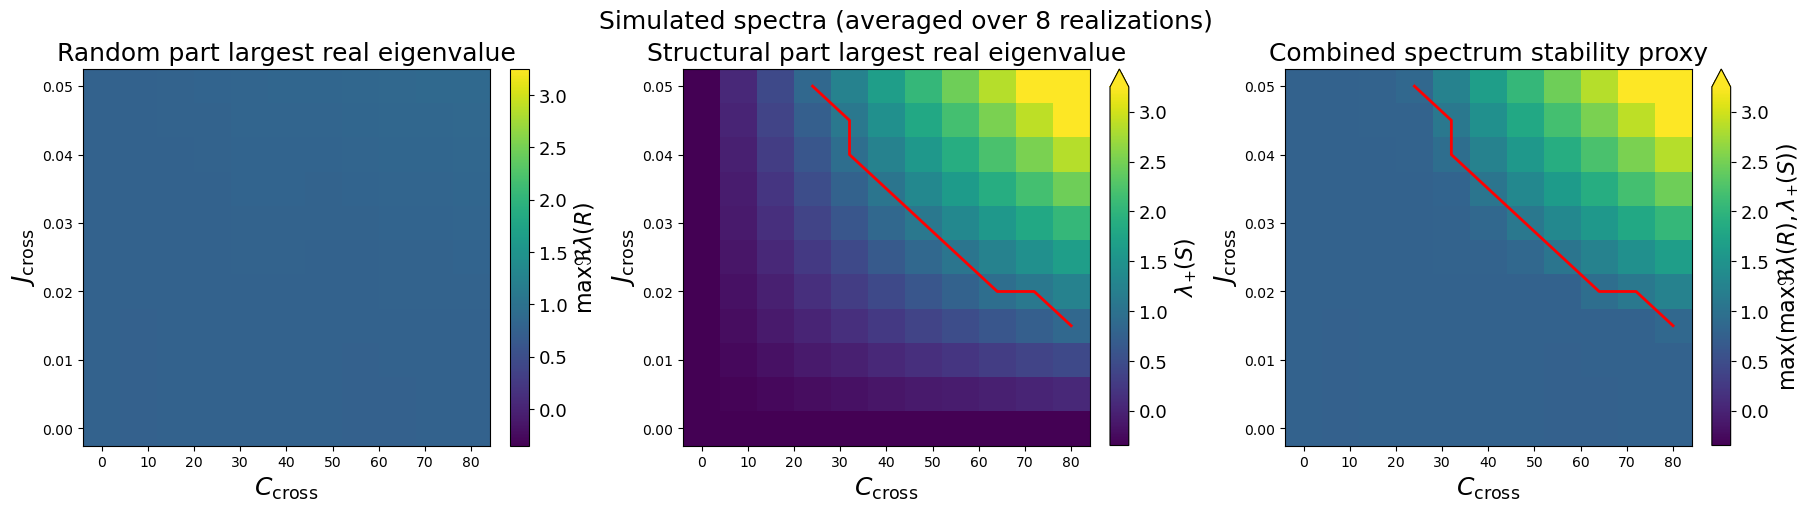

In [13]:
# --- Spectrum triptych on the aggregated multi-realization scan ---
fig, axes = plot_sim_spectra_panels(
    records,
    x_key="C_cross[0,1]",
    y_key="J_cross[0,1]",
    xlabel=r"$C_{\mathrm{cross}}$",
    ylabel=r"$J_{\mathrm{cross}}$",
)
fig.suptitle(
    f"Simulated spectra (averaged over {records[0]['n_realizations']} realizations)",
    fontsize=18,
)
plt.savefig("scan_J_cross_C_cross_J_within035_spectra.png", dpi=300, bbox_inches="tight")
plt.show()

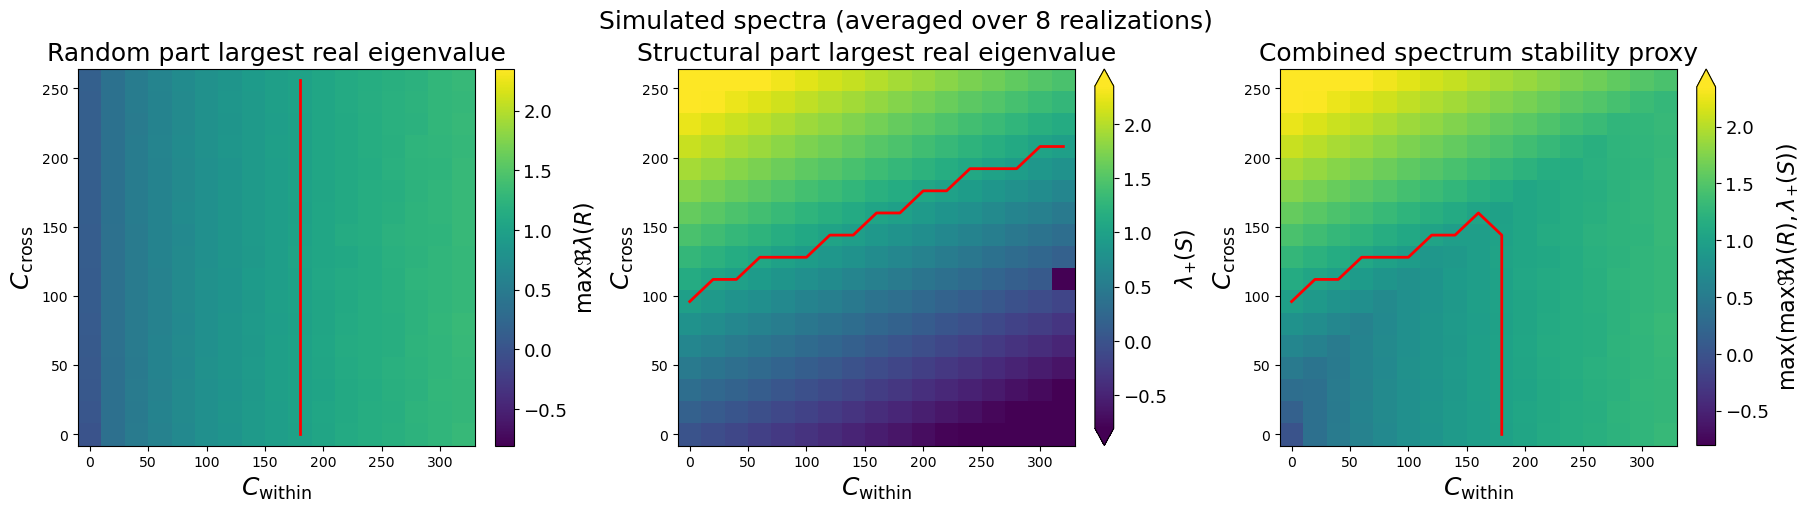

In [28]:
# --- Spectrum triptych on the aggregated multi-realization scan ---
fig, axes = plot_sim_spectra_panels(
    records,
    x_key="C_within[0]",
    y_key="C_cross[0,1]",
    xlabel=r"$C_{\mathrm{within}}$",
    ylabel=r"$C_{\mathrm{cross}}$",
)
fig.suptitle(
    f"Simulated spectra (averaged over {records[0]['n_realizations']} realizations)",
    fontsize=18,
)
plt.savefig("Scan_s_within_s_cross_spectra.png", dpi=300, bbox_inches="tight")
plt.show()

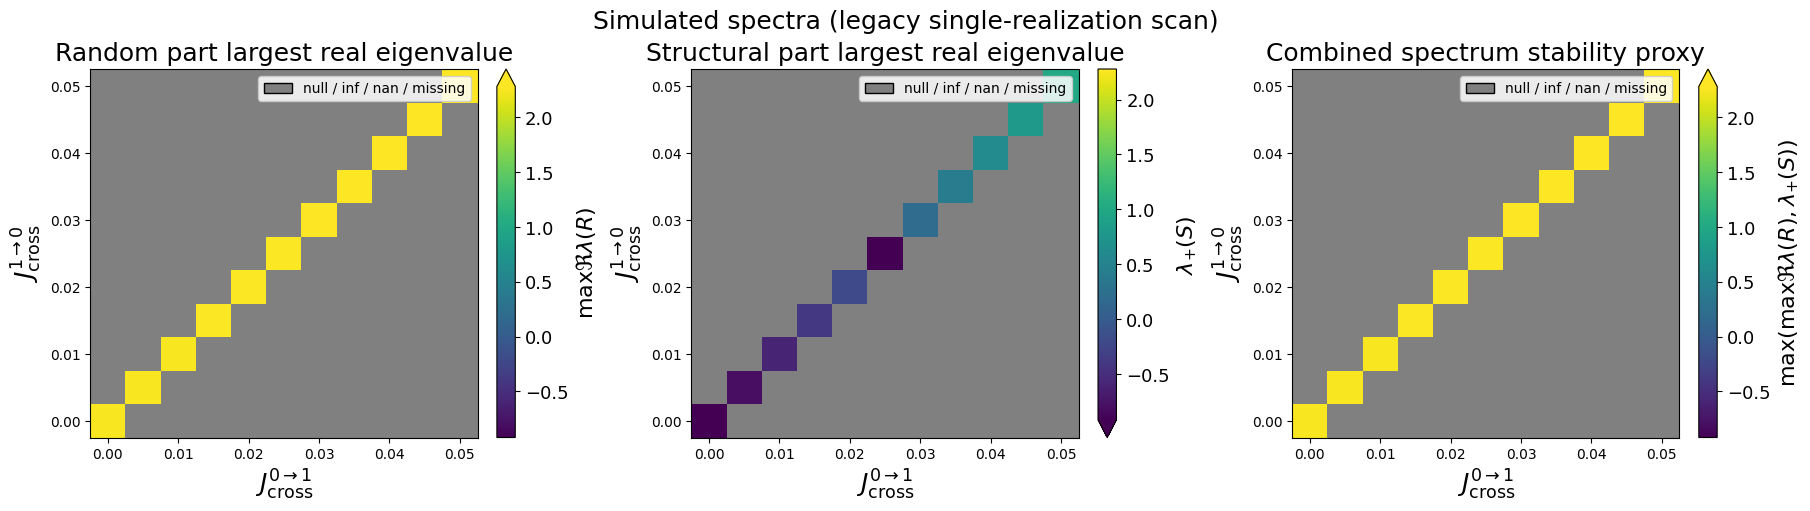

In [12]:
# --- Spectrum triptych on the legacy proportional-J scan ---
fig, axes = plot_sim_spectra_panels(
    records_legacy,
    x_key="J_cross[0,1]",
    y_key="J_cross[1,0]",
    xlabel=r"$J_{\mathrm{cross}}^{0\to 1}$",
    ylabel=r"$J_{\mathrm{cross}}^{1\to 0}$",
)
fig.suptitle("Simulated spectra (legacy single-realization scan)", fontsize=18)
plt.show()

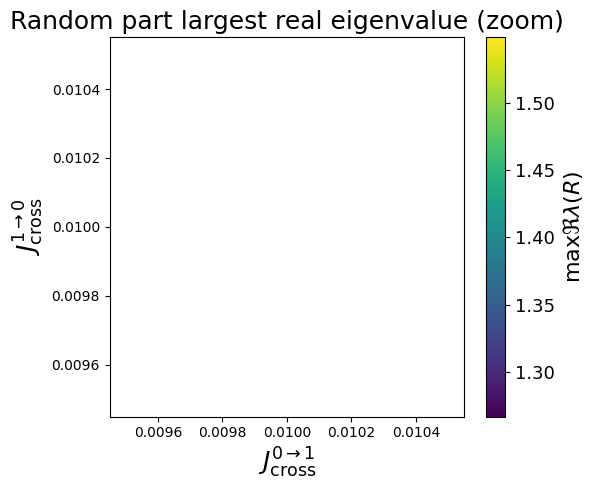

In [13]:
# --- Random-part radius (single panel, zoomed subset) ---
fig, ax = plt.subplots(figsize=(6, 5))
plot_metric_heatmap(
    records_sub,
    x_key="J_cross[0,1]",
    y_key="J_cross[1,0]",
    z_key="R_max_real_eig",
    title="Random part largest real eigenvalue (zoom)",
    xlabel=r"$J_{\mathrm{cross}}^{0\to1}$",
    ylabel=r"$J_{\mathrm{cross}}^{1\to0}$",
    cbar_label=r"$\max\Re\lambda(R)$",
    contour_level=1.0,
    contour_mode="cell_centers",
    ax=ax,
    cmap="viridis",
    clip=True,
)
plt.tight_layout()
plt.show()

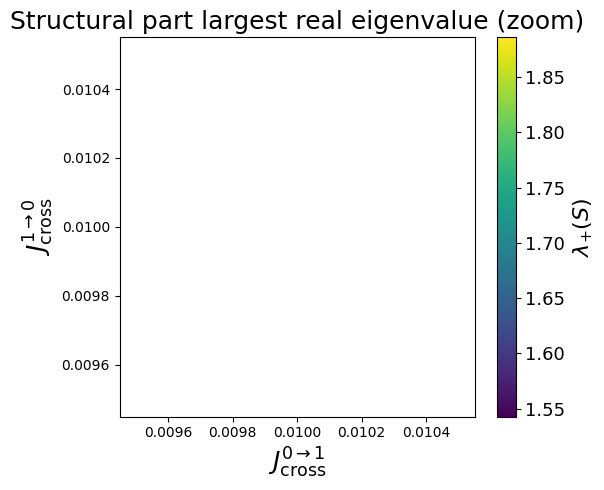

In [14]:
# --- Structural-part largest eigenvalue (single panel, zoomed subset) ---
fig, ax = plt.subplots(figsize=(6, 5))
plot_metric_heatmap(
    records_sub,
    x_key="J_cross[0,1]",
    y_key="J_cross[1,0]",
    z_key="eig_S",
    title="Structural part largest real eigenvalue (zoom)",
    xlabel=r"$J_{\mathrm{cross}}^{0\to1}$",
    ylabel=r"$J_{\mathrm{cross}}^{1\to0}$",
    cbar_label=r"$\lambda_{+}(S)$",
    contour_level=1.0,
    contour_mode="cell_centers",
    ax=ax,
    cmap="viridis",
    clip=True,
)
plt.tight_layout()
plt.show()

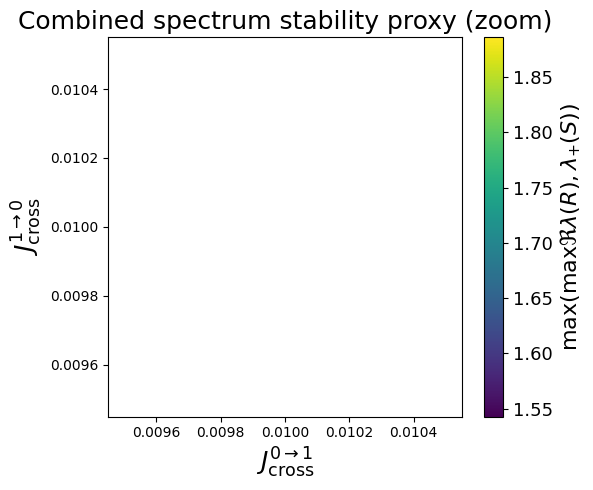

In [15]:
# --- Combined-spectrum stability proxy (zoomed subset) ---
fig, ax = plt.subplots(figsize=(6, 5))
plot_metric_heatmap(
    records_sub,
    x_key="J_cross[0,1]",
    y_key="J_cross[1,0]",
    z_key="W_lambda_max",
    title="Combined spectrum stability proxy (zoom)",
    xlabel=r"$J_{\mathrm{cross}}^{0\to1}$",
    ylabel=r"$J_{\mathrm{cross}}^{1\to0}$",
    cbar_label=r"$\max(\max\Re\lambda(R),\lambda_{+}(S))$",
    contour_level=1.0,
    contour_mode="cell_centers",
    ax=ax,
    cmap="viridis",
    clip=True,
)
plt.tight_layout()
plt.show()

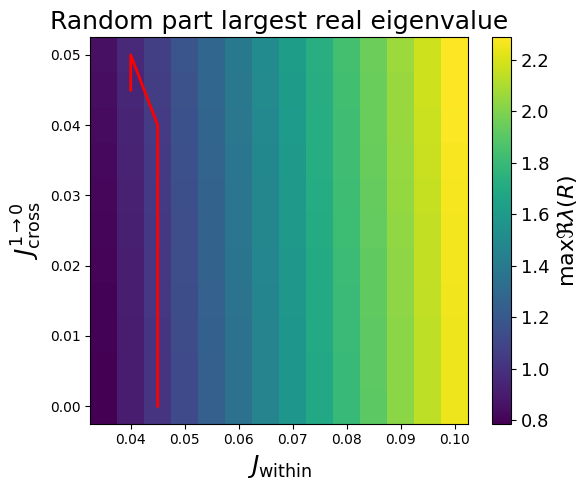

In [16]:
# --- Random part radius across (J_within, J_cross) on the legacy scan ---
fig, ax = plt.subplots(figsize=(6, 5))
plot_metric_heatmap(
    records_legacy,
    x_key="areas[0].J_exc",
    y_key="J_cross[1,0]",
    z_key="R_max_real_eig",
    title="Random part largest real eigenvalue",
    xlabel=r"$J_{\mathrm{within}}$",
    ylabel=r"$J_{\mathrm{cross}}^{1\to0}$",
    cbar_label=r"$\max\Re\lambda(R)$",
    contour_level=1.0,
    contour_mode="cell_centers",
    ax=ax,
    cmap="viridis",
    clip=True,
)
plt.tight_layout()
plt.show()

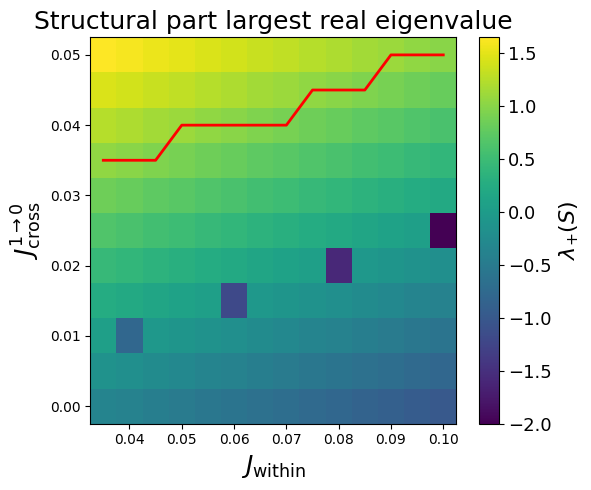

In [17]:
# --- Structural part largest eigenvalue across (J_within, J_cross) ---
fig, ax = plt.subplots(figsize=(6, 5))
plot_metric_heatmap(
    records_legacy,
    x_key="areas[0].J_exc",
    y_key="J_cross[1,0]",
    z_key="eig_S",
    title="Structural part largest real eigenvalue",
    xlabel=r"$J_{\mathrm{within}}$",
    ylabel=r"$J_{\mathrm{cross}}^{1\to0}$",
    cbar_label=r"$\lambda_{+}(S)$",
    contour_level=1.0,
    contour_mode="cell_centers",
    ax=ax,
    cmap="viridis",
    clip=True,
)
plt.tight_layout()
plt.show()

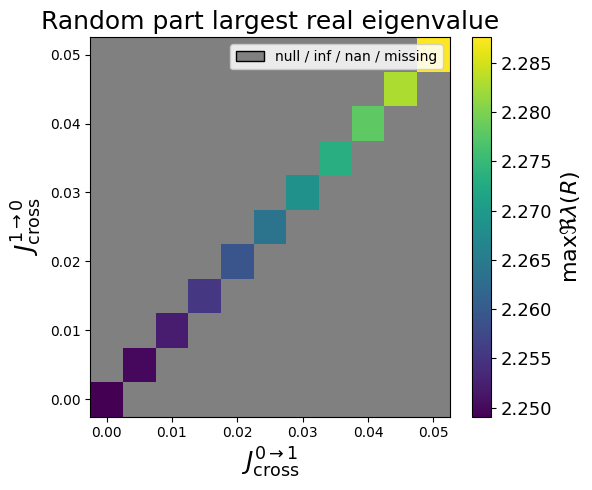

In [18]:
# --- Random part radius across (J_cross[0,1], J_cross[1,0]) on legacy ---
fig, ax = plt.subplots(figsize=(6, 5))
plot_metric_heatmap(
    records_legacy,
    x_key="J_cross[0,1]",
    y_key="J_cross[1,0]",
    z_key="R_max_real_eig",
    title="Random part largest real eigenvalue",
    xlabel=r"$J_{\mathrm{cross}}^{0\to1}$",
    ylabel=r"$J_{\mathrm{cross}}^{1\to0}$",
    cbar_label=r"$\max\Re\lambda(R)$",
    contour_level=1.0,
    contour_mode="cell_centers",
    ax=ax,
    cmap="viridis",
    clip=True,
)
plt.tight_layout()
plt.show()

"""
Sparsity 到临界点导致利用方差的估算失效了
"""

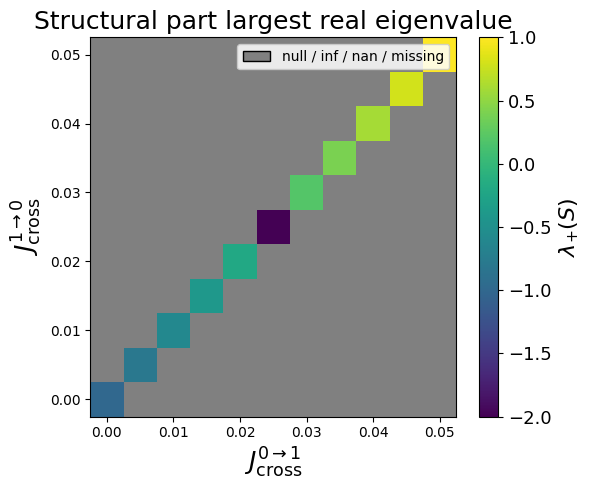

In [19]:
# --- Structural part largest eigenvalue across (J_cross[0,1], J_cross[1,0]) ---
fig, ax = plt.subplots(figsize=(6, 5))
plot_metric_heatmap(
    records_legacy,
    x_key="J_cross[0,1]",
    y_key="J_cross[1,0]",
    z_key="eig_S",
    title="Structural part largest real eigenvalue",
    xlabel=r"$J_{\mathrm{cross}}^{0\to1}$",
    ylabel=r"$J_{\mathrm{cross}}^{1\to0}$",
    cbar_label=r"$\lambda_{+}(S)$",
    contour_level=1.0,
    contour_mode="cell_centers",
    ax=ax,
    cmap="viridis",
    clip=True,
)
plt.tight_layout()
plt.show()